In [ ]:
# Initialisation et imports
# Objectif : charger toutes les librairies necessaires
import ee
import geopandas as gpd
import pandas as pd
import datetime
from shapely.geometry import mapping
from google.colab import drive

drive.mount('/content/drive')
ee.Authenticate()
ee.Initialize(project='gee-ouaga-project')
print("GEE initialise !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE initialise !


In [ ]:
#Zone d etude
# Chargement shapefile Ouagadougou et creation buffer
shapefile_path = "/content/drive/MyDrive/data/Ouaga.shp"
gdf = gpd.read_file(shapefile_path).to_crs(epsg=4326)

# Geometrie complete Ouagadougou
ouaga_geom = ee.Geometry.Polygon(mapping(gdf.geometry[0])['coordinates'])

# Buffer 50km autour du centre ville pour capturer
# les phenomenes atmospheriques venant de l exterieur
ouaga_buffer = ee.Geometry.Point([-1.5144, 12.3647]).buffer(50000)

print("Zone chargee !")
print("Centre : -1.5144, 12.3647")

Zone chargee !
Centre : -1.5144, 12.3647


In [ ]:
#Test disponibilite de toutes les sources
# Objectif : verifier que chaque source est accessible
# avant de lancer l extraction complete

# Source 1 : AAI Sentinel-5P (aerosols)
aai = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI')
       .filterBounds(ouaga_buffer)
       .filterDate('2019-01-01', '2019-12-31')
      )

# Source 2 : NO2 Sentinel-5P (pollution urbaine)
no2 = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
       .filterBounds(ouaga_buffer)
       .filterDate('2019-01-01', '2019-12-31')
      )

# Source 3 : CO Sentinel-5P (feux de brousse)
co = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO')
      .filterBounds(ouaga_buffer)
      .filterDate('2019-01-01', '2019-12-31')
     )

# Source 4 : LST MODIS (temperature surface sol)
lst = (ee.ImageCollection('MODIS/061/MOD11A1')
       .filterBounds(ouaga_buffer)
       .filterDate('2019-01-01', '2019-12-31')
      )

# Source 5 : ERA5 (meteo journaliere)
era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
        .filterBounds(ouaga_buffer)
        .filterDate('2019-01-01', '2019-12-31')
       )

print("DISPONIBILITE DES SOURCES 2019")
print("AAI  Sentinel-5P :", aai.size().getInfo(),  "images")
print("NO2  Sentinel-5P :", no2.size().getInfo(),  "images")
print("CO   Sentinel-5P :", co.size().getInfo(),   "images")
print("LST  MODIS       :", lst.size().getInfo(),  "images")
print("ERA5 Meteo       :", era5.size().getInfo(), "images")

DISPONIBILITE DES SOURCES 2019
AAI  Sentinel-5P : 5147 images
NO2  Sentinel-5P : 5149 images
CO   Sentinel-5P : 5150 images
LST  MODIS       : 364 images
ERA5 Meteo       : 364 images


In [ ]:
#  Test valeurs reelles sur Ouagadougou
# Objectif : verifier que les valeurs sont coherentes
# avant de lancer l extraction complete

date_test  = '2019-04-01'  # Pic Harmattan
date_test2 = '2019-04-02'

# Fonction generique d extraction valeur moyenne
def extract_mean(collection, band, geometry, scale=1000):
    val = (collection
           .filterDate(date_test, date_test2)
           .select(band)
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = geometry,
               scale      = scale,
               bestEffort = True
           )
           .getInfo()
          )
    return val.get(band)

# AAI
aai_val = extract_mean(
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI'),
    'absorbing_aerosol_index',
    ouaga_buffer
)

# NO2
no2_val = extract_mean(
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2'),
    'NO2_column_number_density',
    ouaga_buffer
)

# CO
co_val = extract_mean(
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO'),
    'CO_column_number_density',
    ouaga_buffer
)

# LST MODIS (conversion en Celsius : *0.02 - 273.15)
lst_val = extract_mean(
    ee.ImageCollection('MODIS/061/MOD11A1'),
    'LST_Day_1km',
    ouaga_buffer,
    scale = 1000
)
lst_celsius = round(lst_val * 0.02 - 273.15, 2) if lst_val else None

# ERA5 temperature
era5_val = extract_mean(
    ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR'),
    'temperature_2m',
    ouaga_buffer,
    scale = 1000
)
era5_celsius = round(era5_val - 273.15, 2) if era5_val else None

print("VALEURS 01/04/2019 OUAGADOUGOU")
print(f"AAI (aerosols)    : {aai_val}")
print(f"NO2 (pollution)   : {no2_val}")
print(f"CO  (feux)        : {co_val}")
print(f"LST (sol)         : {lst_celsius} C")
print(f"Temperature ERA5  : {era5_celsius} C")

VALEURS 01/04/2019 OUAGADOUGOU
AAI (aerosols)    : 2.195577537539458
NO2 (pollution)   : 5.107615327393462e-05
CO  (feux)        : 0.046073018370908
LST (sol)         : None C
Temperature ERA5  : 33.31 C


In [ ]:
#Diagnostic LST MODIS
# Objectif : comprendre pourquoi LST = None
# et trouver la bonne bande et le bon scale

# Verifier les bandes disponibles
lst_image = (ee.ImageCollection('MODIS/061/MOD11A1')
             .filterBounds(ouaga_buffer)
             .filterDate('2019-04-01', '2019-04-02')
             .first()
            )

print("Bandes MODIS LST :")
print(lst_image.bandNames().getInfo())

# Tester avec scale natif MODIS = 1000m
val = lst_image.select('LST_Day_1km').reduceRegion(
    reducer    = ee.Reducer.mean(),
    geometry   = ouaga_buffer,
    scale      = 1000,
    bestEffort = True
).getInfo()
print("\nValeur LST scale 1000m :", val)

# Tester avec scale plus large
val2 = lst_image.select('LST_Day_1km').reduceRegion(
    reducer    = ee.Reducer.mean(),
    geometry   = ouaga_buffer,
    scale      = 5000,
    bestEffort = True
).getInfo()
print("Valeur LST scale 5000m :", val2)

# Verifier combien d images disponibles ce jour
count = (ee.ImageCollection('MODIS/061/MOD11A1')
         .filterBounds(ouaga_buffer)
         .filterDate('2019-04-01', '2019-04-02')
         .size()
         .getInfo()
        )
print("\nImages MODIS ce jour :", count)

Bandes MODIS LST :
['LST_Day_1km', 'QC_Day', 'Day_view_time', 'Day_view_angle', 'LST_Night_1km', 'QC_Night', 'Night_view_time', 'Night_view_angle', 'Emis_31', 'Emis_32', 'Clear_day_cov', 'Clear_night_cov']

Valeur LST scale 1000m : {'LST_Day_1km': None}
Valeur LST scale 5000m : {'LST_Day_1km': None}

Images MODIS ce jour : 1


In [ ]:
#  Fonctions d extraction avec ouaga_geom
import datetime

def extract_aai(date_str, next_day_str):
    val = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI')
           .filterDate(date_str, next_day_str)
           .select('absorbing_aerosol_index')
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = ouaga_geom,
               scale      = 1000,
               bestEffort = True
           ).getInfo()
          )
    return val.get('absorbing_aerosol_index')

def extract_no2(date_str, next_day_str):
    val = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
           .filterDate(date_str, next_day_str)
           .select('NO2_column_number_density')
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = ouaga_geom,
               scale      = 1000,
               bestEffort = True
           ).getInfo()
          )
    return val.get('NO2_column_number_density')

def extract_co(date_str, next_day_str):
    val = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO')
           .filterDate(date_str, next_day_str)
           .select('CO_column_number_density')
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = ouaga_geom,
               scale      = 1000,
               bestEffort = True
           ).getInfo()
          )
    return val.get('CO_column_number_density')

def extract_lst(date_str, next_day_str):
    # Moyenne sur 5 jours pour eviter les trous nuageux
    date_obj   = datetime.datetime.strptime(date_str, '%Y-%m-%d')
    date_plus5 = (date_obj + datetime.timedelta(days=5)).strftime('%Y-%m-%d')
    val = (ee.ImageCollection('MODIS/061/MOD11A1')
           .filterDate(date_str, date_plus5)
           .select('LST_Day_1km')
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = ouaga_geom,
               scale      = 1000,
               bestEffort = True
           ).getInfo()
          )
    raw = val.get('LST_Day_1km')
    return round(raw * 0.02 - 273.15, 2) if raw else None

def extract_era5(date_str, next_day_str):
    val = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
           .filterDate(date_str, next_day_str)
           .select([
               'temperature_2m',
               'u_component_of_wind_10m',
               'v_component_of_wind_10m',
               'total_precipitation_sum',
               'dewpoint_temperature_2m',
               'surface_pressure'
           ])
           .mean()
           .reduceRegion(
               reducer    = ee.Reducer.mean(),
               geometry   = ouaga_geom,
               scale      = 1000,
               bestEffort = True
           ).getInfo()
          )
    return {
        'temperature'  : round(val.get('temperature_2m',          273.15) - 273.15, 2),
        'vent_u'       : round(val.get('u_component_of_wind_10m',  0),               3),
        'vent_v'       : round(val.get('v_component_of_wind_10m',  0),               3),
        'precipitation': round((val.get('total_precipitation_sum', 0) or 0) * 1000,  2),
        'humidite'     : round(val.get('dewpoint_temperature_2m',  273.15) - 273.15, 2),
        'pression'     : round((val.get('surface_pressure',        0) or 0) / 100,   2)
    }

print("Fonctions definies avec ouaga_geom !")

Fonctions definies avec ouaga_geom !


In [ ]:
# Test toutes fonctions sur un jour
# Objectif : valider chaque fonction avec ouaga_geom
# avant de lancer la boucle complete

date_test      = '2019-01-15'
date_test_next = '2019-01-16'

print(f"TEST TOUTES FONCTIONS {date_test}\n")

aai_val  = extract_aai(date_test, date_test_next)
no2_val  = extract_no2(date_test, date_test_next)
co_val   = extract_co(date_test, date_test_next)
lst_val  = extract_lst(date_test, date_test_next)
era5_val = extract_era5(date_test, date_test_next)

print(f"AAI          : {aai_val}")
print(f"NO2          : {no2_val}")
print(f"CO           : {co_val}")
print(f"LST          : {lst_val} C")
print(f"Temperature  : {era5_val['temperature']} C")
print(f"Vent U       : {era5_val['vent_u']} m/s")
print(f"Vent V       : {era5_val['vent_v']} m/s")
print(f"Precipitation: {era5_val['precipitation']} mm")
print(f"Humidite     : {era5_val['humidite']} C")
print(f"Pression     : {era5_val['pression']} hPa")

TEST TOUTES FONCTIONS 2019-01-15

AAI          : -0.0035718091482241235
NO2          : 5.819169662550267e-05
CO           : 0.036387592148200705
LST          : 37.64 C
Temperature  : 26.16 C
Vent U       : -1.554 m/s
Vent V       : -1.396 m/s
Precipitation: 0 mm
Humidite     : -4.45 C
Pression     : 977.01 hPa


In [ ]:
#Extraction complete 2018-2025
# Sauvegarde intermediaire tous les 30 jours

import pandas as pd
import datetime

start_date = datetime.date(2018, 6, 1)
end_date   = datetime.date(2025, 12, 31)
delta      = datetime.timedelta(days=1)
save_path  = "/content/drive/MyDrive/Ouaga_Grid/ouaga_stress_env_raw.csv"

records = []
current = start_date
total   = (end_date - start_date).days

print(f"Periode    : {start_date} -> {end_date}")
print(f"Total jours: {total}")
print("Debut extraction...\n")

while current <= end_date:
    next_day     = current + delta
    date_str     = str(current)
    next_day_str = str(next_day)

    try:
        aai_val  = extract_aai(date_str,  next_day_str)
        no2_val  = extract_no2(date_str,  next_day_str)
        co_val   = extract_co(date_str,   next_day_str)
        lst_val  = extract_lst(date_str,  next_day_str)
        era5_val = extract_era5(date_str, next_day_str)

        records.append({
            'date'         : date_str,
            'AAI'          : aai_val,
            'NO2'          : no2_val,
            'CO'           : co_val,
            'LST'          : lst_val,
            'temperature'  : era5_val['temperature'],
            'vent_u'       : era5_val['vent_u'],
            'vent_v'       : era5_val['vent_v'],
            'precipitation': era5_val['precipitation'],
            'humidite'     : era5_val['humidite'],
            'pression'     : era5_val['pression']
        })

    except Exception as e:
        # En cas d erreur continuer sans perdre les donnees
        print(f"Erreur {date_str} : {e}")
        records.append({'date': date_str})

    # Sauvegarde intermediaire tous les 30 jours
    if len(records) % 30 == 0:
        pd.DataFrame(records).to_csv(save_path, index=False)
        print(f"{date_str} : {len(records)}/{total} jours traites")

    current = next_day

# Sauvegarde finale
df = pd.DataFrame(records)
df.to_csv(save_path, index=False)

print(f"\nExtraction terminee !")
print(f"Total lignes       : {len(df)}")
print(f"Valeurs manquantes :\n{df.isnull().sum()}")
print(f"Fichier sauvegarde : {save_path}")

Periode    : 2018-06-01 -> 2025-12-31
Total jours: 2770
Debut extraction...

2018-06-30 : 30/2770 jours traites
2018-07-30 : 60/2770 jours traites
2018-08-29 : 90/2770 jours traites
2018-09-28 : 120/2770 jours traites
2018-10-28 : 150/2770 jours traites
2018-11-27 : 180/2770 jours traites
2018-12-27 : 210/2770 jours traites
2019-01-26 : 240/2770 jours traites
2019-02-25 : 270/2770 jours traites
2019-03-27 : 300/2770 jours traites


2019-04-26 : 330/2770 jours traites
2019-05-26 : 360/2770 jours traites
2019-06-25 : 390/2770 jours traites
2019-07-25 : 420/2770 jours traites
2019-08-24 : 450/2770 jours traites
2019-09-23 : 480/2770 jours traites
2019-10-23 : 510/2770 jours traites
2019-11-22 : 540/2770 jours traites
2019-12-22 : 570/2770 jours traites
2020-01-21 : 600/2770 jours traites
2020-02-20 : 630/2770 jours traites
2020-03-21 : 660/2770 jours traites
2020-04-20 : 690/2770 jours traites
2020-05-20 : 720/2770 jours traites
2020-06-19 : 750/2770 jours traites
2020-07-19 : 780/2770 jours traites
2020-08-18 : 810/2770 jours traites
2020-09-17 : 840/2770 jours traites
2020-10-17 : 870/2770 jours traites
2020-11-16 : 900/2770 jours traites
2020-12-16 : 930/2770 jours traites
2021-01-15 : 960/2770 jours traites
2021-02-14 : 990/2770 jours traites
2021-03-16 : 1020/2770 jours traites
2021-04-15 : 1050/2770 jours traites
2021-05-15 : 1080/2770 jours traites
2021-06-14 : 1110/2770 jours traites
2021-07-14 : 1140/2770 j

2022-12-06 : 1650/2770 jours traites
2023-01-05 : 1680/2770 jours traites
2023-02-04 : 1710/2770 jours traites
2023-03-06 : 1740/2770 jours traites
2023-04-05 : 1770/2770 jours traites
2023-05-05 : 1800/2770 jours traites
2023-06-04 : 1830/2770 jours traites
2023-07-04 : 1860/2770 jours traites
2023-08-03 : 1890/2770 jours traites
2023-09-02 : 1920/2770 jours traites
2023-10-02 : 1950/2770 jours traites
2023-11-01 : 1980/2770 jours traites
2023-12-01 : 2010/2770 jours traites
2023-12-31 : 2040/2770 jours traites
2024-01-30 : 2070/2770 jours traites
2024-02-29 : 2100/2770 jours traites
2024-03-30 : 2130/2770 jours traites
2024-04-29 : 2160/2770 jours traites
2024-05-29 : 2190/2770 jours traites
2024-06-28 : 2220/2770 jours traites
2024-07-28 : 2250/2770 jours traites
2024-08-27 : 2280/2770 jours traites
2024-09-26 : 2310/2770 jours traites
2024-10-26 : 2340/2770 jours traites
2024-11-25 : 2370/2770 jours traites
2024-12-25 : 2400/2770 jours traites
2025-01-24 : 2430/2770 jours traites
2

In [ ]:
# Verification distribution et coherence
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_stress_env_raw.csv")

print("STATISTIQUES DESCRIPTIVES\n")
print(df.describe().round(3).to_string())

STATISTIQUES DESCRIPTIVES

            AAI     NO2        CO       LST  temperature    vent_u    vent_v  precipitation  humidite  pression
count  2727.000  2698.0  2313.000  2556.000     2771.000  2771.000  2771.000       2771.000  2771.000  2771.000
mean      0.178     0.0     0.038    35.915       28.782     0.034     0.343          1.728    12.563   975.511
std       0.930     0.0     0.006     4.010        2.959     1.385     1.561          5.066    10.509     1.850
min      -2.292    -0.0     0.026    20.310       19.790    -3.441    -3.612          0.000   -12.650   969.480
25%      -0.506     0.0     0.034    33.368       26.580    -1.214    -1.246          0.000     2.095   974.330
50%       0.185     0.0     0.037    35.810       28.210     0.365     0.840          0.010    17.600   975.690
75%       0.828     0.0     0.041    38.590       30.930     1.156     1.632          0.850    21.870   976.795
max       5.400     0.0     0.068    49.760       36.230     3.086     3.249 

In [ ]:
# Verification NO2 et CO en detail
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_stress_env_raw.csv")

print("=== NO2 valeurs reelles ===")
print(df['NO2'].describe())
print("\nExemples valeurs NO2 :")
print(df['NO2'].dropna().head(10).tolist())

print("\n=== CO valeurs reelles ===")
print(df['CO'].describe())
print("\nExemples valeurs CO :")
print(df['CO'].dropna().head(10).tolist())

=== NO2 valeurs reelles ===
count    2698.000000
mean        0.000064
std         0.000013
min        -0.000008
25%         0.000055
50%         0.000063
75%         0.000071
max         0.000139
Name: NO2, dtype: float64

Exemples valeurs NO2 :
[4.6851989183903736e-05, 4.080433535760857e-05, 7.179770351641176e-05, 6.861448063452639e-05, 5.409724856235785e-05, 6.673615269900961e-05, 6.862191110806162e-05, 6.458671209220501e-05, 5.634632284568497e-05, 8.372912919035358e-05]

=== CO valeurs reelles ===
count    2313.000000
mean        0.037751
std         0.005648
min         0.025636
25%         0.033679
50%         0.036561
75%         0.040735
max         0.068419
Name: CO, dtype: float64

Exemples valeurs CO :
[0.0300019507533807, 0.0299510766928791, 0.0307721768656775, 0.0321846238557815, 0.0336685515610177, 0.0301073864102363, 0.0331802495536972, 0.0344415371540049, 0.0307665314256237, 0.0315154759514134]


=== MOYENNES MENSUELLES ===

       AAI    LST  temperature  precipitation
mois                                         
1     0.32  34.69        25.71           0.00
2     0.59  36.71        27.96           0.00
3     0.75  39.58        31.98           0.09
4     0.54  40.50        33.60           0.17
5     0.59  36.99        33.09           0.57
6     0.25  33.98        30.54           1.69
7    -0.05  32.23        27.56           4.15
8    -0.53  31.69        26.09           7.42
9    -0.39  33.10        26.92           4.28
10   -0.06  36.32        28.47           1.23
11    0.16  38.43        28.33           0.00
12    0.23  35.12        26.26           0.00


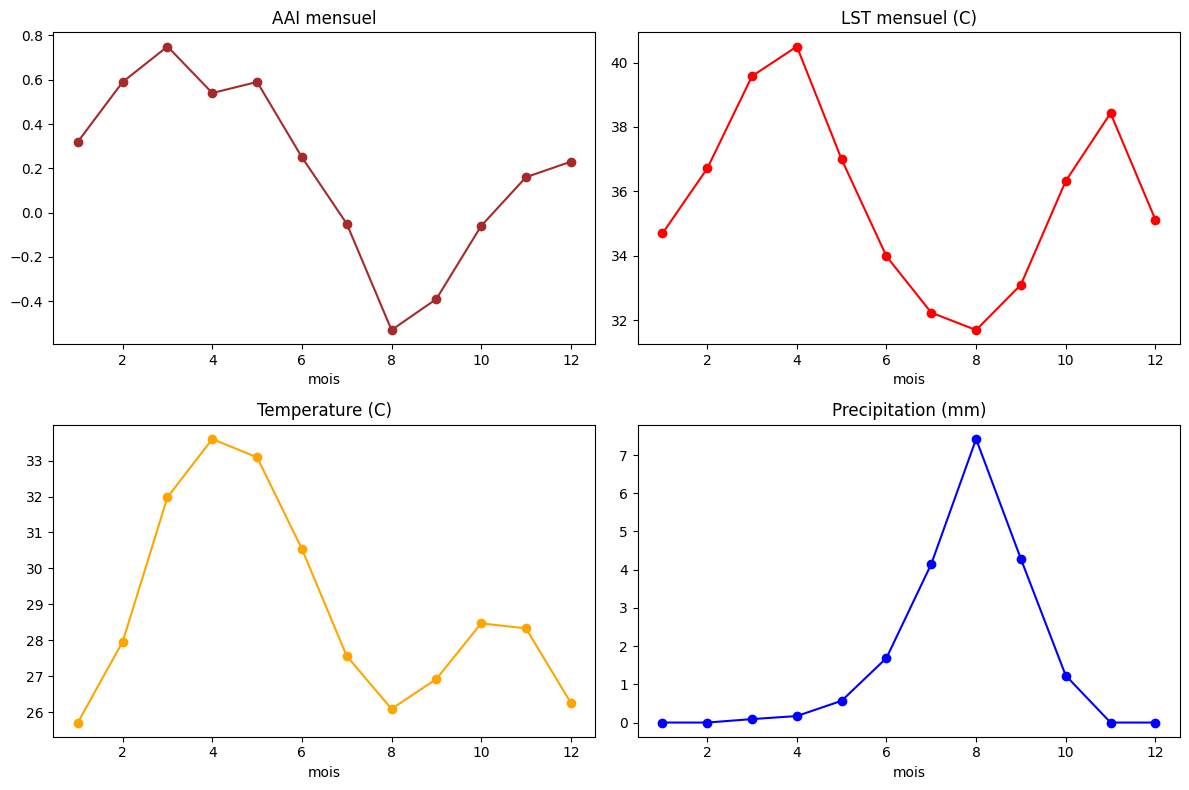

Graphique sauvegarde !


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_stress_env_raw.csv")
df['date'] = pd.to_datetime(df['date'])
df['mois'] = df['date'].dt.month

# Moyenne mensuelle de chaque variable
monthly = df.groupby('mois')[['AAI','LST','temperature','precipitation']].mean().round(2)

print("=== MOYENNES MENSUELLES ===\n")
print(monthly.to_string())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

monthly['AAI'].plot(ax=axes[0,0], title='AAI mensuel', marker='o', color='brown')
monthly['LST'].plot(ax=axes[0,1], title='LST mensuel (C)', marker='o', color='red')
monthly['temperature'].plot(ax=axes[1,0], title='Temperature (C)', marker='o', color='orange')
monthly['precipitation'].plot(ax=axes[1,1], title='Precipitation (mm)', marker='o', color='blue')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Ouaga_Grid/saisonnalite.png")
plt.show()
print("Graphique sauvegarde !")

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_stress_env_raw.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Conversion NO2 en micromoles pour lisibilite
df['NO2'] = df['NO2'] * 1e6

print(f"Dataset charge : {df.shape}")
print(f"Periode : {df['date'].min()} -> {df['date'].max()}")
print(f"Valeurs manquantes :\n{df.isnull().sum()}")

Dataset charge : (2771, 11)
Periode : 2018-06-01 00:00:00 -> 2025-12-31 00:00:00
Valeurs manquantes :
date               0
AAI               44
NO2               73
CO               458
LST              215
temperature        0
vent_u             0
vent_v             0
precipitation      0
humidite           0
pression           0
dtype: int64


In [ ]:
# Gestion valeurs manquantes
# Interpolation lineaire pour les series temporelles
# Plus adapte que mean/median pour donnees journalieres

df['AAI'] = df['AAI'].interpolate(method='linear')
df['NO2'] = df['NO2'].interpolate(method='linear')
df['CO']  = df['CO'].interpolate(method='linear')
df['LST'] = df['LST'].interpolate(method='linear')

print("Valeurs manquantes apres interpolation :")
print(df.isnull().sum())
print(f"\nDataset complet : {df.shape}")

Valeurs manquantes apres interpolation :
date              0
AAI              27
NO2              27
CO               35
LST               0
temperature       0
vent_u            0
vent_v            0
precipitation     0
humidite          0
pression          0
dtype: int64

Dataset complet : (2771, 11)


In [ ]:
# Les valeurs restantes sont en debut ou fin de serie
# On utilise forward fill puis backward fill

df['AAI'] = df['AAI'].fillna(method='ffill').fillna(method='bfill')
df['NO2'] = df['NO2'].fillna(method='ffill').fillna(method='bfill')
df['CO']  = df['CO'].fillna(method='ffill').fillna(method='bfill')

print("Valeurs manquantes finales :")
print(df.isnull().sum())
print("\nDataset pret pour feature engineering !")

Valeurs manquantes finales :
date             0
AAI              0
NO2              0
CO               0
LST              0
temperature      0
vent_u           0
vent_v           0
precipitation    0
humidite         0
pression         0
dtype: int64

Dataset pret pour feature engineering !


/tmp/ipykernel_156/3948877868.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['AAI'] = df['AAI'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_156/3948877868.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_156/3948877868.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CO']  = df['CO'].fillna(method='ffill').fillna(method='bfill')


In [ ]:
# Feature engineering
# Objectif : créer toutes les variables derivees
# pour enrichir le dataset avant le ML

# 1. Variables temporelles
df['mois']       = df['date'].dt.month
df['jour_annee'] = df['date'].dt.dayofyear
df['jour_semaine']= df['date'].dt.dayofweek

# Encodage cyclique mois et jour
# Evite que Decembre(12) soit loin de Janvier(1)
df['mois_sin']   = np.sin(2 * np.pi * df['mois'] / 12)
df['mois_cos']   = np.cos(2 * np.pi * df['mois'] / 12)
df['jour_sin']   = np.sin(2 * np.pi * df['jour_annee'] / 365)
df['jour_cos']   = np.cos(2 * np.pi * df['jour_annee'] / 365)

# Saison : 1=seche (Nov-Avr) 0=pluies (Mai-Oct)
df['saison_seche'] = df['mois'].isin([11,12,1,2,3,4]).astype(int)

print("Variables temporelles creees !")

# 2. Lags AAI (valeurs passees)
df['AAI_lag1']  = df['AAI'].shift(1)
df['AAI_lag3']  = df['AAI'].shift(3)
df['AAI_lag7']  = df['AAI'].shift(7)
df['AAI_lag14'] = df['AAI'].shift(14)
df['AAI_lag30'] = df['AAI'].shift(30)

print("Lags AAI crees !")

# 3. Moyennes glissantes AAI
df['AAI_roll7']  = df['AAI'].rolling(window=7,  min_periods=1).mean()
df['AAI_roll14'] = df['AAI'].rolling(window=14, min_periods=1).mean()
df['AAI_roll30'] = df['AAI'].rolling(window=30, min_periods=1).mean()

print("Moyennes glissantes creees !")

# 4. Variables derivees meteo
# Vitesse et direction du vent
df['vitesse_vent']   = np.sqrt(df['vent_u']**2 + df['vent_v']**2)
df['direction_vent'] = np.degrees(np.arctan2(df['vent_v'], df['vent_u']))

# Delta temperature jour/nuit
df['humidite_relative'] = df['humidite'] / df['temperature']

# Anomalie AAI par rapport moyenne 30 jours
df['anomalie_AAI'] = df['AAI'] - df['AAI_roll30']

# Index Harmattan : AAI fort + vent du nord-est
df['index_harmattan'] = df['AAI'] * df['vitesse_vent']

print("Variables derivees meteo creees !")

# 5. Lags LST et temperature
df['LST_lag1']  = df['LST'].shift(1)
df['LST_lag7']  = df['LST'].shift(7)
df['temp_lag1'] = df['temperature'].shift(1)

print("Lags LST et temperature crees !")

# 6. Variable cible ISE
# Index de Stress Environnemental
# Normalisation de chaque composante entre 0 et 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
aai_norm = scaler.fit_transform(df[['AAI']])
lst_norm = scaler.fit_transform(df[['LST']])
no2_norm = scaler.fit_transform(df[['NO2']])

# ISE = combinaison ponderee
df['ISE'] = (0.5 * aai_norm.flatten() +
             0.3 * lst_norm.flatten() +
             0.2 * no2_norm.flatten())

# Variable cible : ISE jour suivant
df['ISE_t1'] = df['ISE'].shift(-1)

print("ISE et variable cible crees !")

print(f"\nDataset final : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

Variables temporelles creees !
Lags AAI crees !
Moyennes glissantes creees !
Variables derivees meteo creees !
Lags LST et temperature crees !
ISE et variable cible crees !

Dataset final : (2771, 37)
Colonnes : ['date', 'AAI', 'NO2', 'CO', 'LST', 'temperature', 'vent_u', 'vent_v', 'precipitation', 'humidite', 'pression', 'mois', 'jour_annee', 'jour_semaine', 'mois_sin', 'mois_cos', 'jour_sin', 'jour_cos', 'saison_seche', 'AAI_lag1', 'AAI_lag3', 'AAI_lag7', 'AAI_lag14', 'AAI_lag30', 'AAI_roll7', 'AAI_roll14', 'AAI_roll30', 'vitesse_vent', 'direction_vent', 'humidite_relative', 'anomalie_AAI', 'index_harmattan', 'LST_lag1', 'LST_lag7', 'temp_lag1', 'ISE', 'ISE_t1']


In [ ]:
# Poids scientifiques par entropie Shannon
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
aai_norm = scaler.fit_transform(df[['AAI']]).flatten()
lst_norm = scaler.fit_transform(df[['LST']]).flatten()
no2_norm = scaler.fit_transform(df[['NO2']]).flatten()

X = np.column_stack([aai_norm, lst_norm, no2_norm])

def entropy_weight(X):
    n   = X.shape[0]
    X   = np.clip(X, 1e-10, None)
    P   = X / X.sum(axis=0)
    E   = -np.sum(P * np.log(P), axis=0) / np.log(n)
    D   = 1 - E
    W   = D / D.sum()
    return W

poids = entropy_weight(X)

print("=== POIDS PAR ENTROPIE SHANNON ===\n")
print(f"AAI (Harmattan)  : {poids[0]*100:.1f}%")
print(f"LST (Chaleur)    : {poids[1]*100:.1f}%")
print(f"NO2 (Industrie)  : {poids[2]*100:.1f}%")

df['ISE']    = (poids[0]*aai_norm + poids[1]*lst_norm + poids[2]*no2_norm)
df['ISE_t1'] = df['ISE'].shift(-1)

print(f"\nISE calcule scientifiquement !")
print(df['ISE'].describe().round(3))

=== POIDS PAR ENTROPIE SHANNON ===

AAI (Harmattan)  : 58.3%
LST (Chaleur)    : 29.1%
NO2 (Industrie)  : 12.6%

ISE calcule scientifiquement !
count    2771.000
mean        0.398
std         0.089
min         0.127
25%         0.337
50%         0.400
75%         0.461
max         0.746
Name: ISE, dtype: float64


In [ ]:
so2 = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_SO2')
       .filterBounds(ouaga_geom)
       .filterDate('2019-01-01', '2019-12-31')
      )
print("SO2 disponible :", so2.size().getInfo())

# Valeur test
val = (so2.select('SO2_column_number_density')
          .mean()
          .reduceRegion(
              reducer    = ee.Reducer.mean(),
              geometry   = ouaga_geom,
              scale      = 1000,
              bestEffort = True
          ).getInfo()
      )
print("Valeur SO2 2019 :", val)

SO2 disponible : 5143
Valeur SO2 2019 : {'SO2_column_number_density': 6.425328458625398e-06}


In [ ]:
# Comparaison ACP vs Entropie Shannon
# pour la creation de la variable cible ISE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
aai_norm = scaler.fit_transform(df[['AAI']]).flatten()
lst_norm = scaler.fit_transform(df[['LST']]).flatten()
no2_norm = scaler.fit_transform(df[['NO2']]).flatten()

X = np.column_stack([aai_norm, lst_norm, no2_norm])

# ACP
pca = PCA(n_components=3)
pca.fit(X)

print("=== RESULTATS ACP ===\n")
print("Variance expliquee par composante :")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1} : {v*100:.1f}%")

print("\nPoids ACP sur PC1 :")
print(f"AAI : {pca.components_[0][0]*100:.1f}%")
print(f"LST : {pca.components_[0][1]*100:.1f}%")
print(f"NO2 : {pca.components_[0][2]*100:.1f}%")

# ISE par ACP (PC1)
pc1 = pca.transform(X)[:,0]
pc1_norm = (pc1 - pc1.min()) / (pc1.max() - pc1.min())

print("\nCOMPARAISON ISE\n")
print(f"{'':20} {'Entropie':>10} {'ACP':>10}")
print(f"{'AAI':20} {58.3:>10.1f}% {abs(pca.components_[0][0])*100:>10.1f}%")
print(f"{'LST':20} {29.1:>10.1f}% {abs(pca.components_[0][1])*100:>10.1f}%")
print(f"{'NO2':20} {12.6:>10.1f}% {abs(pca.components_[0][2])*100:>10.1f}%")

# Correlation entre les deux ISE
corr = np.corrcoef(df['ISE'].values, pc1_norm)[0,1]
print(f"\nCorrelation ISE_entropie vs ISE_ACP : {corr:.3f}")

=== RESULTATS ACP ===

Variance expliquee par composante :
PC1 : 49.8%
PC2 : 36.3%
PC3 : 13.9%

Poids ACP sur PC1 :
AAI : 37.4%
LST : 88.1%
NO2 : 29.0%

COMPARAISON ISE

                       Entropie        ACP
AAI                        58.3%       37.4%
LST                        29.1%       88.1%
NO2                        12.6%       29.0%

Correlation ISE_entropie vs ISE_ACP : 0.825


In [ ]:
# Feature engineering complementaire

# Lags ISE
df['ISE_lag1']  = df['ISE'].shift(1)
df['ISE_lag7']  = df['ISE'].shift(7)
df['ISE_roll7'] = df['ISE'].rolling(window=7,  min_periods=1).mean()
df['ISE_roll14']= df['ISE'].rolling(window=14, min_periods=1).mean()

# Lags NO2 et CO
df['NO2_lag1'] = df['NO2'].shift(1)
df['NO2_lag7'] = df['NO2'].shift(7)
df['CO_lag1']  = df['CO'].shift(1)
df['CO_lag7']  = df['CO'].shift(7)

# Variables derivees supplementaires
df['delta_ISE']          = df['ISE'] - df['ISE_lag1']
df['delta_temp']         = df['temperature'] - df['temp_lag1']
df['precipitation_roll7']= df['precipitation'].rolling(window=7, min_periods=1).mean()
df['vitesse_vent_lag1']  = df['vitesse_vent'].shift(1)

print(f"Dataset enrichi : {df.shape}")
print(f"Nouvelles colonnes ajoutees !")
print(f"Total features : {df.shape[1]}")

Dataset enrichi : (2771, 49)
Nouvelles colonnes ajoutees !
Total features : 49


In [ ]:
# Suppression NaN dues aux lags
df_ml = df.dropna().reset_index(drop=True)

save_path = "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_ml.csv"
df_ml.to_csv(save_path, index=False)

print(f"Dataset ML final sauvegarde !")
print(f"Lignes      : {df_ml.shape[0]}")
print(f"Colonnes    : {df_ml.shape[1]}")
print(f"Periode     : {df_ml['date'].min()} -> {df_ml['date'].max()}")
print(f"Manquants   : {df_ml.isnull().sum().sum()}")
print(f"\nListe colonnes :")
print(list(df_ml.columns))

Dataset ML final sauvegarde !
Lignes      : 2740
Colonnes    : 49
Periode     : 2018-07-01 00:00:00 -> 2025-12-30 00:00:00
Manquants   : 0

Liste colonnes :
['date', 'AAI', 'NO2', 'CO', 'LST', 'temperature', 'vent_u', 'vent_v', 'precipitation', 'humidite', 'pression', 'mois', 'jour_annee', 'jour_semaine', 'mois_sin', 'mois_cos', 'jour_sin', 'jour_cos', 'saison_seche', 'AAI_lag1', 'AAI_lag3', 'AAI_lag7', 'AAI_lag14', 'AAI_lag30', 'AAI_roll7', 'AAI_roll14', 'AAI_roll30', 'vitesse_vent', 'direction_vent', 'humidite_relative', 'anomalie_AAI', 'index_harmattan', 'LST_lag1', 'LST_lag7', 'temp_lag1', 'ISE', 'ISE_t1', 'ISE_lag1', 'ISE_lag7', 'ISE_roll7', 'ISE_roll14', 'NO2_lag1', 'NO2_lag7', 'CO_lag1', 'CO_lag7', 'delta_ISE', 'delta_temp', 'precipitation_roll7', 'vitesse_vent_lag1']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_ml = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_ml.csv")

# Variables numeriques seulement
# Exclure date et variables cibles
features = [c for c in df_ml.columns
            if c not in ['date', 'ISE_t1']]

# Correlation avec AAI
corr_aai = df_ml[features].corr()['AAI'].sort_values(ascending=False)

print("=== CORRELATION AVEC AAI ===\n")
print(corr_aai.round(3).to_string())

=== CORRELATION AVEC AAI ===

AAI                    1.000
index_harmattan        0.944
ISE                    0.871
AAI_roll7              0.746
anomalie_AAI           0.736
AAI_roll14             0.687
AAI_roll30             0.650
ISE_roll7              0.622
ISE_roll14             0.588
AAI_lag1               0.575
ISE_lag1               0.510
delta_ISE              0.454
AAI_lag7               0.390
ISE_lag7               0.388
mois_sin               0.386
AAI_lag3               0.374
AAI_lag14              0.371
jour_sin               0.370
NO2                    0.340
temperature            0.327
AAI_lag30              0.300
temp_lag1              0.276
CO_lag7                0.254
saison_seche           0.254
CO_lag1                0.252
CO                     0.235
NO2_lag7               0.181
delta_temp             0.165
NO2_lag1               0.148
jour_cos               0.132
LST_lag7               0.122
vitesse_vent           0.110
vitesse_vent_lag1      0.077
LST_lag1     

In [ ]:
# Variables cibles
df_ml['AAI_t3']       = df_ml['AAI'].shift(-3)
df_ml['harmattan_bin']= (df_ml['AAI'] >= 1).astype(int)

# Features supplementaires
df_ml['AAI_lag2']     = df_ml['AAI'].shift(2)
df_ml['pluie_bin']    = (df_ml['precipitation'] > 0).astype(int)
df_ml['vent_nord']    = (df_ml['vent_v'] < 0).astype(int)

print("Variables ajoutees !")
print(f"Dataset : {df_ml.shape}")

print("\nDistribution harmattan_bin :")
print(df_ml['harmattan_bin'].value_counts())
print(f"\nPourcentage dangereux : {df_ml['harmattan_bin'].mean()*100:.1f}%")

Variables ajoutees !
Dataset : (2740, 54)

Distribution harmattan_bin :
harmattan_bin
0    2231
1     509
Name: count, dtype: int64

Pourcentage dangereux : 18.6%


In [ ]:
# Correlation des nouvelles features
# avec les deux variables cibles

print("=== CORRELATION AVEC harmattan_bin ===\n")
corr_bin = df_ml.drop(columns=['date','ISE_t1']).corr()['harmattan_bin']
corr_bin = corr_bin.drop('harmattan_bin').sort_values(ascending=False)
print(corr_bin.round(3).to_string())

print("\nCORRELATION AVEC AAI_t3\n")
corr_t3 = df_ml.drop(columns=['date','ISE_t1']).corr()['AAI_t3']
corr_t3 = corr_t3.drop('AAI_t3').sort_values(ascending=False)
print(corr_t3.round(3).to_string())

=== CORRELATION AVEC harmattan_bin ===

AAI                    0.682
index_harmattan        0.670
ISE                    0.595
AAI_roll7              0.530
AAI_roll14             0.495
AAI_roll30             0.484
anomalie_AAI           0.466
ISE_roll7              0.445
ISE_roll14             0.430
AAI_lag1               0.398
ISE_lag1               0.354
jour_sin               0.322
mois_sin               0.312
delta_ISE              0.303
AAI_lag2               0.297
temperature            0.290
AAI_lag14              0.286
AAI_t3                 0.282
AAI_lag3               0.281
ISE_lag7               0.266
temp_lag1              0.262
AAI_lag7               0.257
AAI_lag30              0.254
NO2                    0.225
CO_lag7                0.223
CO_lag1                0.218
CO                     0.207
NO2_lag7               0.156
saison_seche           0.130
NO2_lag1               0.107
LST_lag7               0.092
delta_temp             0.088
vitesse_vent           0.079
ven

In [ ]:
# Nettoyage final dataset ML
# Suppression data leakage et variables inutiles

cols_supprimer = [
    # Data leakage : contiennent directement AAI
    'index_harmattan',
    'ISE',
    'ISE_lag1',
    'ISE_lag7',
    'ISE_roll7',
    'ISE_roll14',
    'ISE_t1',
    'delta_ISE',
    'anomalie_AAI',
    # Inutiles : correlation quasi nulle
    'jour_semaine',
    'jour_cos',
    # Redondants : remplaces par versions ameliorees
    'vent_u',
    'vent_v',
    'direction_vent',
    'mois',
    'jour_annee',
    # Date pas une feature ML
    'date'
]

df_final = df_ml.drop(columns=cols_supprimer).dropna().reset_index(drop=True)

print(f"Features avant : {df_ml.shape[1]}")
print(f"Features apres : {df_final.shape[1]}")
print(f"Lignes         : {df_final.shape[0]}")
print(f"Manquants      : {df_final.isnull().sum().sum()}")

print(f"\nFeatures finales :")
for col in df_final.columns:
    print(f"  -> {col}")

df_final.to_csv(
    "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv",
    index=False
)
print("\nDataset final sauvegarde !")

Features avant : 54
Features apres : 37
Lignes         : 2735
Manquants      : 0

Features finales :
  -> AAI
  -> NO2
  -> CO
  -> LST
  -> temperature
  -> precipitation
  -> humidite
  -> pression
  -> mois_sin
  -> mois_cos
  -> jour_sin
  -> saison_seche
  -> AAI_lag1
  -> AAI_lag3
  -> AAI_lag7
  -> AAI_lag14
  -> AAI_lag30
  -> AAI_roll7
  -> AAI_roll14
  -> AAI_roll30
  -> vitesse_vent
  -> humidite_relative
  -> LST_lag1
  -> LST_lag7
  -> temp_lag1
  -> NO2_lag1
  -> NO2_lag7
  -> CO_lag1
  -> CO_lag7
  -> delta_temp
  -> precipitation_roll7
  -> vitesse_vent_lag1
  -> AAI_t3
  -> harmattan_bin
  -> AAI_lag2
  -> pluie_bin
  -> vent_nord

Dataset final sauvegarde !


In [53]:
# Calculer correlation AAI avec differents horizons
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv")

print("=== CORRELATION AAI avec differents horizons ===\n")

for j in [1, 2, 3, 5, 7, 14]:
    corr = df['AAI'].corr(df['AAI'].shift(-j))
    print(f"AAI J+{j:2d} : {corr:.3f}")

=== CORRELATION AAI avec differents horizons ===

AAI J+ 1 : 0.575
AAI J+ 2 : 0.405
AAI J+ 3 : 0.375
AAI J+ 5 : 0.554
AAI J+ 7 : 0.390
AAI J+14 : 0.374


In [54]:
# Correlation harmattan_bin avec AAI differents jours
print("=== CORRELATION harmattan_bin avec AAI ===\n")

# Correlation harmattan_bin actuel avec AAI passes
for j in [1, 2, 3, 5, 7]:
    corr = df['harmattan_bin'].corr(df['AAI'].shift(j))
    print(f"harmattan_bin vs AAI J-{j} : {corr:.3f}")

print()

# Correlation harmattan_bin futur avec AAI actuel
for j in [1, 2, 3, 5, 7]:
    corr = df['harmattan_bin'].corr(df['harmattan_bin'].shift(-j))
    print(f"harmattan_bin J+{j} vs harmattan_bin J : {corr:.3f}")

=== CORRELATION harmattan_bin avec AAI ===

harmattan_bin vs AAI J-1 : 0.398
harmattan_bin vs AAI J-2 : 0.297
harmattan_bin vs AAI J-3 : 0.281
harmattan_bin vs AAI J-5 : 0.401
harmattan_bin vs AAI J-7 : 0.257

harmattan_bin J+1 vs harmattan_bin J : 0.410
harmattan_bin J+2 vs harmattan_bin J : 0.296
harmattan_bin J+3 vs harmattan_bin J : 0.268
harmattan_bin J+5 vs harmattan_bin J : 0.413
harmattan_bin J+7 vs harmattan_bin J : 0.260


In [55]:
# Creer harmattan_bin_t3 = Harmattan dans 3 jours
df['harmattan_bin_t3'] = df['harmattan_bin'].shift(-3)

print("Distribution harmattan_bin_t3 :")
print(df['harmattan_bin_t3'].value_counts())
print(f"\nPourcentage dangereux J+3 : {df['harmattan_bin_t3'].mean()*100:.1f}%")

# Sauvegarder
df.to_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv", index=False)
print("\nDataset mis a jour !")

Distribution harmattan_bin_t3 :
harmattan_bin_t3
0.0    2224
1.0     508
Name: count, dtype: int64

Pourcentage dangereux J+3 : 18.6%

Dataset mis a jour !
